In [1]:
# Aim: Implement RNN and LSTM, compare their forecasting performance, and predict future values using a public time-series dataset

In [2]:
import os, random, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] ="2"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Tensorflow: ", tf.__version__)

Tensorflow:  2.18.0


In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

fallback = [
112,118,132,129,121,135,148,148,136,119,104,118,
115,126,141,135,125,149,170,170,158,133,114,140,
145,150,178,163,172,178,199,199,184,162,146,166,
171,180,193,181,183,218,230,242,209,191,172,194,
196,196,236,235,229,243,264,272,237,211,180,201,
204,188,235,227,234,264,302,293,259,229,203,229,
242,233,267,269,270,315,364,347,312,274,237,278,
284,277,317,313,318,374,413,405,355,306,271,306,
315,301,356,348,355,422,465,467,404,347,305,336,
340,318,362,348,363,435,491,505,404,359,310,337,
360,342,406,396,420,472,548,559,463,407,362,405,
417,391,419,461,472,535,622,606,508,461,390,432
]

try:
    df = pd.read_csv(url)
    df.columns = ["Month","Passengers"]
    df["Month"] = pd.date_to_time(df["Month"])
except:
    df = pd.DataFrame({
        "Month": pd.date_range("1949-01-01", periods=144, freq="MS"),
        "Passengers": fallback
    })
display(df.head())
print(df.shape)

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


(144, 2)


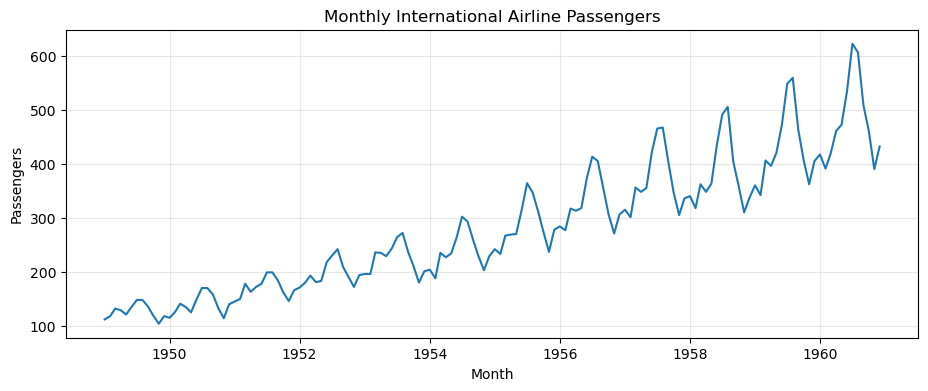

In [5]:
plt.figure(figsize=(11,4))
plt.plot(df["Month"], df["Passengers"])
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Monthly International Airline Passengers")
plt.grid(alpha=0.3)
plt.show()

In [6]:
# perpare time series

LOOKBACK = 12
values = df["Passengers"].values.reshape(-1,1).astype("float32")
train_size = int(len(values)*0.8)

scaler = MinMaxScaler()
scaler.fit(values[:train_size])
scaled = scaler.transform(values)

def make_sequences(data, start, end, lookback):
    X, y, idx = [],[],[]
    for i in range(start,end):
        X.append(data[i-lookback:i])
        y.append(data[i])
        idx.append(i)
    return np.array(X), np.array(y), np.array(idx)

X_train, y_train, _ = make_sequences(scaled, LOOKBACK, train_size, LOOKBACK)
X_test, y_test, test_idx = make_sequences(scaled, train_size, len(scaled), LOOKBACK)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (103, 12, 1)
X_test: (29, 12, 1)


In [7]:
rnn = Sequential([
    Input(shape=(LOOKBACK, 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])
rnn.compile(optimizer="adam", loss="mse")
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
lstm = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(32),
    Dense(1)
])
lstm.compile(optimizer="adam", loss="mse")
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
rnn_hist = rnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)
lstm_hist = lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)
print("Training done")

Training done


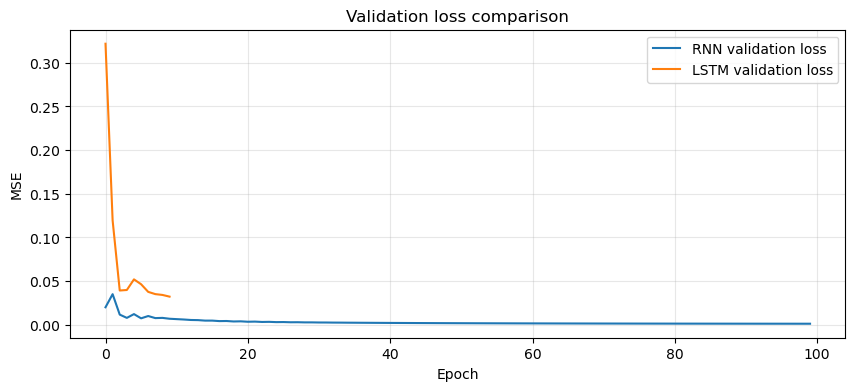

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_hist.history["val_loss"],label = "RNN validation loss")
plt.plot(lstm_hist.history["val_loss"],label = "LSTM validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Validation loss comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [11]:
rnn_pred = scaler.inverse_transform(rnn.predict(X_test, verbose=0)).flatten()
lstm_pred = scaler.inverse_transform(lstm.predict(X_test, verbose=0)).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

def metrics(y, p):
    return [
        mean_absolute_error(y, p),
        np.sqrt(mean_squared_error(y, p)),
        mean_absolute_percentage_error(y,p)*100
    ]
rnn_m = metrics(actual, rnn_pred)
lstm_m = metrics(actual, lstm_pred)

result = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM"],
    "MAE": [rnn_m[0], lstm_m[0]],
    "RMSE": [rnn_m[1], lstm_m[1]],
    "MAPE": [rnn_m[2], lstm_m[2]],
    "Parameters": [rnn.count_params(), lstm.count_params()]
})

display(result.round(3))
best = result.loc[result["RMSE"].idxmin(),"Model"]
print(best)

,Model,MAE,RMSE,MAPE,Parameters
0,Simple RNN,27.076000,34.020000,5.818,1121
1,LSTM,262.253998,274.033997,58.299,4385


Simple RNN


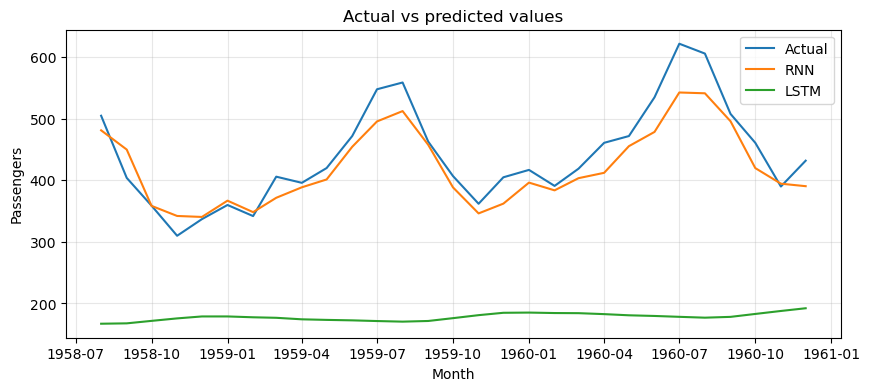

In [12]:
dates = df["Month"].iloc[test_idx]
plt.figure(figsize=(10,4))
plt.plot(dates, actual, label = "Actual")
plt.plot(dates, rnn_pred, label = "RNN")
plt.plot(dates, lstm_pred, label = "LSTM")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Actual vs predicted values")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [13]:
# future forecasting 

def future_forecast(model, data, steps=12):
    window = data[-LOOKBACK:].copy()
    out=[]
    for _ in range(steps):
        x = window.reshape(1, LOOKBACK,1)
        pred = model.predict(x, verbose=0)[0,0]
        out.append(pred)
        window = np.vstack([window[1:], [[pred]]])
    return scaler.inverse_transform(np.array(out).reshape(-1,1)).flatten()

STEPS = 12
rnn_future = future_forecast(rnn, scaled, STEPS)
lstmfuture = future_forecast(lstm, scaled, STEPS)

future_dates = pd.date_range(
    df["Month"].iloc[-1] + pd.offsets.MonthBegin(1),
    periods = STEPS,
    freq="MS"
)

future = pd.DataFrame({
    "Month": future_dates,
    "RNN": rnn_future,
    "LSTM": lstmfuture
})
display(future.round(3))

,Month,RNN,LSTM
0,1961-01-01,435.000000,192.608994
1,1961-02-01,394.148987,197.145996
2,1961-03-01,412.174988,195.880997
3,1961-04-01,431.135010,190.822006
4,1961-05-01,459.683990,184.000000
5,1961-06-01,502.329010,176.804001
6,1961-07-01,548.655029,169.576004
7,1961-08-01,534.768005,162.625000
8,1961-09-01,500.011993,156.766998
9,1961-10-01,456.419006,152.343002


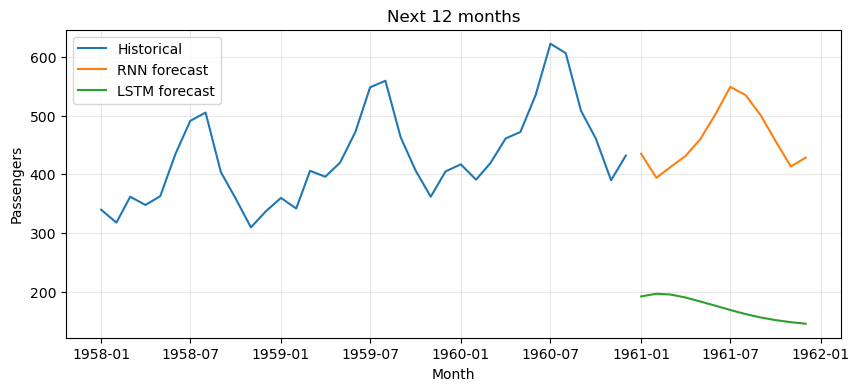

In [14]:
plt.figure(figsize=(10,4))
plt.plot(df["Month"].iloc[-36:], df["Passengers"].iloc[-36:], label="Historical")
plt.plot(future["Month"].iloc[-36:], future["RNN"], label="RNN forecast")
plt.plot(future["Month"].iloc[-36:], future["LSTM"], label="LSTM forecast")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Next 12 months")
plt.grid(alpha=0.3)
plt.legend()
plt.show()